In [ ]:
# Data Engineering Practicals
   #   Practical-4
# Name: Insiya Shoeb Bobde
# Rollno: 06
# Student-id: 5115304

In [1]:
#QUE: python program demonstrating Noise Elimination, Feature Selection, and Exploratory Data Analysis (EDA) using Pandas, NumPy, Matplotlib, and Scikit-learn
import pandas as pd

data = {
    'Age': [20, 21, 22, 23, 24, 100],
    'Marks': [75, 80, 85, 90, 95, 20],
    'Attendance': [85, 88, 90, 92, 94, 50],
    'Constant': [1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

print("Original Dataset:")
print(df)

Original Dataset:
   Age  Marks  Attendance  Constant
0   20     75          85         1
1   21     80          88         1
2   22     85          90         1
3   23     90          92         1
4   24     95          94         1
5  100     20          50         1


In [3]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df['Age'] >= lower) & (df['Age'] <= upper)]

print("\nDataset after Noise Elimination:")
print(df_clean)



Dataset after Noise Elimination:
   Age  Marks  Attendance  Constant
0   20     75          85         1
1   21     80          88         1
2   22     85          90         1
3   23     90          92         1
4   24     95          94         1


In [5]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.0)

selected = selector.fit_transform(df_clean)

selected_columns = df_clean.columns[selector.get_support()]

print("Selected columns:")
print(selected_columns)

Selected columns:
Index(['Age', 'Marks', 'Attendance'], dtype='str')


In [6]:
print("\nDataset Information:")
print(df_clean.info())

print("\nStatistical Summary:")
print(df_clean.describe())

print("\nCorrelation Matrix:")
print(df_clean.corr())



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Age         5 non-null      int64
 1   Marks       5 non-null      int64
 2   Attendance  5 non-null      int64
 3   Constant    5 non-null      int64
dtypes: int64(4)
memory usage: 232.0 bytes
None

Statistical Summary:
             Age      Marks  Attendance  Constant
count   5.000000   5.000000     5.00000       5.0
mean   22.000000  85.000000    89.80000       1.0
std     1.581139   7.905694     3.49285       0.0
min    20.000000  75.000000    85.00000       1.0
25%    21.000000  80.000000    88.00000       1.0
50%    22.000000  85.000000    90.00000       1.0
75%    23.000000  90.000000    92.00000       1.0
max    24.000000  95.000000    94.00000       1.0

Correlation Matrix:
                 Age     Marks  Attendance  Constant
Age         1.000000  1.000000    0.995893       NaN
Marks   

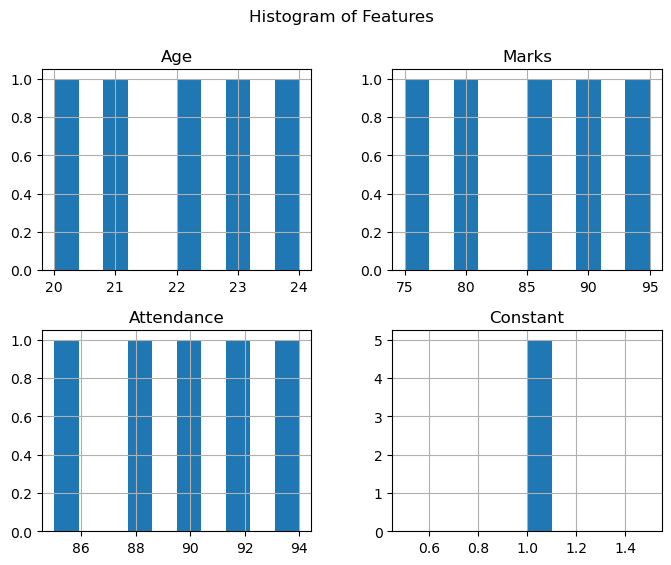

In [8]:
import matplotlib.pyplot as plt

df_clean.hist(figsize=(8, 6))
plt.suptitle("Histogram of Features")
plt.show()

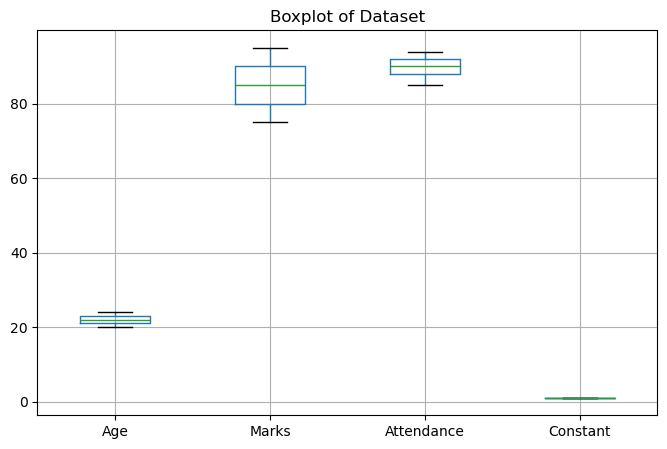

In [9]:
df_clean.boxplot(figsize=(8,5))
plt.title("Boxplot of Dataset")
plt.show()